## Middleware

Middleware provides a way to more tightly control what happens inside the agent.Middleware is useful for the following :

Tracking agent behaviour with logging,analytics and debugging.

Transforming prompts, tool selection and output formatting.

Adding retries, fallbacks and early termination logic.

Applying rate limits, guardrails PII detection.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key=os.getenv('GROQ_API_KEY')
#print(groq_api_key)

from langchain_groq import ChatGroq

model=ChatGroq(
    model="llama-3.1-8b-instant"
    # model="llama-3.1-70b"
)
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F0267156D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F0268784D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
response=model.invoke(" what is summarisation middleware")

# print(response)
# response['content']
# response.content

### Summarization Middleware

Automatically summarize conversation history when approaching token limits,preserving recent messages while compressing older context.Summarization is useful for the following.

Long-Running conversation that exceeds context windows.

Mutli-turn dailogues with extensive history

Application where preserving full conversation context matters.

In [1]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.types import Checkpointer
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage


#messagebased summarizer
agents=create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)



NameError: name 'model' is not defined

In [ ]:
#run with thread 
config={"configurable":{"thread_id":"convo-1"}}

#sample conversation
question=[
    "who is bulleya?",
    "what does sharhad mean?",
    "when is the next bus from Nift college to Kudulu gate",
    "how to be fanshionable?",
    "what is meaning of being simple?",
    "how did albert einstein died?",
    "how not to miss someone?",
    "Does eys speak?",
    "Am i a fool?",
    "How can be increse our life span anything aprt from diet?"
]

for q in question:
    response=agents.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages:{response}")
    print(f"Messages{len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='who is bulleya?', additional_kwargs={}, response_metadata={}, id='fe983c8b-b1d0-4ae5-b2e0-691f6947cd7b'), AIMessage(content="Bulleya is a song from the 2016 Indian film 'Ae Dil Hai Mushkil', sung by Amit Mishra and Monali Thakur. The song's lyrics are written by Amitabh Bhattacharya. \n\nHowever, I assume you are asking about the 'Bulleya' from the 2020 Indian film 'Shubh Mangal Zyada Saavdhan', starring Ayushmann Khurrana, which is a modern take on the traditional concept of bullying.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 41, 'total_tokens': 145, 'completion_time': 0.197256013, 'completion_tokens_details': None, 'prompt_time': 0.075947819, 'prompt_tokens_details': None, 'queue_time': 0.08918344, 'total_time': 0.273203832}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_p

KeyboardInterrupt: 

Summarization based on Token Size

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

@tool
def search_hotels(city :str)-> str:
    """ search for hotels in a given city.Use this tool whenever the user asks to find hotels ."""
    return f"""Hotel in {city}:
    1.Grand Hotel - 5 start, $788/night , spa ,pool , gym , yoga
    2.City INN - 4 star , $550/night, food , business centre
    3.Budget stay - 3 star , $333/night , free wifi"""


agent2 = create_agent(
    model= model , 
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model=model , 
            trigger=("tokens",400),
            keep=("tokens",123)
        )


    ]
)


config = {"configurable":{"thread_id":"new-convo-2"}}

In [ ]:
from langchain_core.messages.utils import count_tokens_approximately
#run test
cities =["paris","vakanda","nigeria","tokyo","Dubai","Kathmandu"]

for city in cities:
    response = agent2.invoke(
        {"messages":[HumanMessage(content=f"Find hotels in {city}")]},
        config=config 
    )

    token = count_tokens_approximately(response["messages"])
    print(f"{city}:~{token} tokens, {len(response['messages'])} messages")
    print(f"{response['messages']}")
    

paris:~150 tokens, 4 messages
[HumanMessage(content='Find hotels in paris', additional_kwargs={}, response_metadata={}, id='cb615ead-214e-4147-9cff-f5d10ed7e421'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'n0kav6jyw', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 242, 'total_tokens': 257, 'completion_time': 0.021382301, 'completion_tokens_details': None, 'prompt_time': 0.015819214, 'prompt_tokens_details': None, 'queue_time': 0.052993201, 'total_time': 0.037201515}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efe67-7522-7d60-925b-de00ae2d78a0-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'n0kav6jyw', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={

Summarization based on Fraction

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city: str) -> str:
    """
    Search hotels in a city.

    Use this tool whenever a user asks:
    - hotels
    - accommodation
    - lodging
    - places to stay
    """
    return f"""
    Hotels in {city}
    Grand Hotel $435
    City Inn $249
    Budget Stay $120
    """

#low fraction for testing
agent3=create_agent(
    model=model,
    tools=[search_hotel],
    checkpointer=InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model=model,
            trigger=("fraction",0.005),
            keep=("fraction",0.002),
        ),
    ],
)


config = {"configurable":{"thread_id":"new-fract-convo-3"}}

In [ ]:
#token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4


#test sample
cities =["paris","vakanda","nigeria","tokyo","Dubai","Kathmandu"]

for city in cities:
    response = agent3.invoke(
        {"messages":[HumanMessage(content=f"Find hotels in {city}")]},
        config=config 
    )

    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000
    print(f"{city}:~{token} tokens ({fraction :.4f}), {len(response['messages'])} messages")
    print(f"{response['messages']}")

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'brave_search' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=brave_search>{"query": "hotels in Paris prices"}</function>'}}

## Human in the Loop Middleware

Pause agent execution for human approval , editing or rejection of tool calls before they execute .
Human-in-the-loop is useful for the following:

* High-stakes operations requiring human approval (e.g database writes, financial transaction).

* Compliance workflows where human oversight is mandatory

* Long-running conversation where human feedback guides the agent.

In [1]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str)-> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID:{email_id}"


def send_email_tool(recipient : str , subject : str, body :str )-> str:
    """ Mock function to send an email ."""
    return f"Email send to {recipient} with the subject {subject}"


In [4]:
#creating an agent 
agent=create_agent(
    model = model , 
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
    
)

# config= {"configurable":{"thread_id":"test-check"}}


In [25]:
# step -1 request
from langchain.messages import HumanMessage

result = agent.invoke(
    # {"messages":[HumanMessage(content="send email to hips2@line.com with subject 'middlewarw check' and body 'kaam kar rha h bidu , aab aage dekhte h kya hota .'")]},
    {"messages":[HumanMessage(content="send email to hips2@line.com with subject 'middlewarw check' and body 'planned the trip successfully .'")]},
    config=config
)




In [21]:
result 

{'messages': [HumanMessage(content="send email to hips2@line.com with subject 'middlewarw check' and body 'kaam kar rha h bidu , aab aage dekhte h kya hota .'", additional_kwargs={}, response_metadata={}, id='7b6553f8-9341-47d8-8eb4-e889cf26e8f9'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gw51tazm9', 'function': {'arguments': '{"body":"kaam kar rha h bidu , aab aage dekhte h kya hota .","recipient":"hips2@line.com","subject":"middlewarw check"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 333, 'total_tokens': 388, 'completion_time': 0.061919275, 'completion_tokens_details': None, 'prompt_time': 0.018414404, 'prompt_tokens_details': None, 'queue_time': 0.055600385, 'total_time': 0.080333679}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

from the above response we can see that the agent wait for human approval to send email.

In [26]:
# step 2 : Approve
from langgraph.types import Command

if "__interrupt__" in result:
    print("Paused aprroving ")

    result = agent.invoke(
        Command(
            resume={
                "decisions":[{"type":"approve"}]
            }
        ),
        config=config
    )
    
    print(f"Result :{result['messages'][-1].content}")



Paused aprroving 
Result :Note: The email body contains a message about planning a trip successfully.


In [27]:
result

{'messages': [HumanMessage(content="send email to hips2@line.com with subject 'middlewarw check' and body 'kaam kar rha h bidu , aab aage dekhte h kya hota .'", additional_kwargs={}, response_metadata={}, id='7b6553f8-9341-47d8-8eb4-e889cf26e8f9'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gw51tazm9', 'function': {'arguments': '{"body":"kaam kar rha h bidu , aab aage dekhte h kya hota .","recipient":"hips2@line.com","subject":"middlewarw check"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 333, 'total_tokens': 388, 'completion_time': 0.061919275, 'completion_tokens_details': None, 'prompt_time': 0.018414404, 'prompt_tokens_details': None, 'queue_time': 0.055600385, 'total_time': 0.080333679}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

### Reject

In [6]:
from langchain.messages import HumanMessage
config={"configurable":{"thread_id":"test-reject-1"}}

# step-1 reject
result=agent.invoke(
    {"messages":[HumanMessage(content="send a message to bareth_nihkhik.com with subject 'Update check' and body 'regarding his cricket career'")]},
    config = config
)

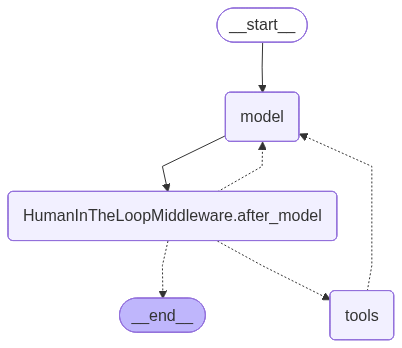

In [32]:
agent

In [45]:
config

{'configurable': {'thread_id': 'test-reject-1'}}

In [8]:
# step-2 reject 
from langgraph.types import Command

if "__interrupt__" in result:
    print("Paused Approving...")


    result = agent.invoke(
        Command(
            resume= {"decisions":[{"type":"reject"}]}
        ),
        config= config,
    )

    print(f"Result : {result['messages'][-1].content}")
    

Paused Approving...
Result : I'm sorry, I'm unable to provide information about that.


In [10]:
result

{'messages': [HumanMessage(content="send a message to bareth_nihkhik.com with subject 'Update check' and body 'regarding his cricket career'", additional_kwargs={}, response_metadata={}, id='1d9b9f30-ea3e-4982-bc2e-5a175658d914'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ft6qcqatv', 'function': {'arguments': '{"body":"regarding his cricket career","recipient":"bareth_nihkhik.com","subject":"Update check"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 319, 'total_tokens': 356, 'completion_time': 0.042154198, 'completion_tokens_details': None, 'prompt_time': 0.019225203, 'prompt_tokens_details': None, 'queue_time': 0.049072916, 'total_time': 0.061379401}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f45ae-a666-7652-a4c3-bab7308c00c

### Editing

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str)-> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID:{email_id}"


def send_email_tool(recipient : str , subject : str, body :str )-> str:
    """ Mock function to send an email ."""
    return f"Email send to {recipient} with the subject {subject}"


#creating an agent 
agent=create_agent(
    model = model , 
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
    
)

config= {"configurable":{"thread_id":"test-edit-1"}}


In [5]:
# Fresh thread for the edit test
config = {"configurable": {"thread_id": "test-edit-1"}}  # new, unused thread_id

# Step 1: trigger a new interrupt
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Send email to test@example.com saying hello"}]},
    config=config,
)

In [7]:
result

{'messages': [HumanMessage(content='Send email to test@example.com saying hello', additional_kwargs={}, response_metadata={}, id='fa0065bf-4bd5-4b91-a933-9ce5fdd0955d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '764048p80', 'function': {'arguments': '{"body":"Hello from email tool!","recipient":"test@example.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 301, 'total_tokens': 334, 'completion_time': 0.044406652, 'completion_tokens_details': None, 'prompt_time': 0.019575255, 'prompt_tokens_details': None, 'queue_time': 0.049850844, 'total_time': 0.063981907}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4638-8250-7641-9bde-b7ec448a9126-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {

In [9]:
# step-2 reject 
from langgraph.types import Command

if "__interrupt__" in result:
    print("Paused Editing...")


    result = agent.invoke(
    Command(
        resume={
            "decisions": [{
                "type": "edit",
                "edited_action": {
                    "name": "send_email_tool",
                    "args": {
                        "recipient": "someone@example.com",
                        "subject": "Updated subject",
                        "body": "Updated body text by HUman"
                        }
                    }
                }]
            }
        ),
        config=config,
    )

    # print(f"Result : {result['messages'][-1].content}")


Paused Editing...


In [10]:
result

{'messages': [HumanMessage(content='Send email to test@example.com saying hello', additional_kwargs={}, response_metadata={}, id='fa0065bf-4bd5-4b91-a933-9ce5fdd0955d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '764048p80', 'function': {'arguments': '{"body":"Hello from email tool!","recipient":"test@example.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 301, 'total_tokens': 334, 'completion_time': 0.044406652, 'completion_tokens_details': None, 'prompt_time': 0.019575255, 'prompt_tokens_details': None, 'queue_time': 0.049850844, 'total_time': 0.063981907}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4638-8250-7641-9bde-b7ec448a9126-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'someone